In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, fbeta_score, accuracy_score
)
import matplotlib.pyplot as plt
import glob
import unicodedata
from xgboost import XGBClassifier

RANDOM_STATE = 5

In [57]:
def evaluate(preds, y, target_names, title=""):
    """Print report + F2, show confusion matrix. Returns the predictions."""
    print(f"--- {title} ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=target_names))
    #print(f"F2-score: {fbeta_score(y, preds, beta=2):.4f}\n")
    cm = confusion_matrix(y, preds) #labels=target_names)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(title)
    return preds

# Data Preparation

In [58]:
files = glob.glob("data/*.csv")

### Loading and Cleaning
First we must concatenate all 8 csv files. They have odd column names with trailing spaces, so names must be normalised. We then clean any rows that contain infinity or NaNs.

In [59]:
df = (
    pd.concat((pd.read_csv(f, encoding_errors="replace") for f in files), ignore_index=True)
    .rename(columns=lambda s: s.strip())
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

### Down-Casting
Down-casting from float64 is inherantly lossy, so below checks if loss > 1e-07 when casting to float32. 

In [60]:
for col in df.select_dtypes("float").columns:
    orig = df[col].astype("float64")
    back = df[col].astype("float32").astype("float64")
    
    # largest relative error introduced
    rel_err = ((back - orig).abs() / orig.abs().replace(0, np.nan)).max()
    print(col, rel_err)

Fwd Packet Length Mean 5.8808532115861154e-08
Fwd Packet Length Std 5.946117860918782e-08
Bwd Packet Length Mean 5.894248777797077e-08
Bwd Packet Length Std 5.9490018992827366e-08
Flow Bytes/s 5.952342611128164e-08
Flow Packets/s 5.9561211665086304e-08
Flow IAT Mean 5.960429305881185e-08
Flow IAT Std 5.9494370761997505e-08
Fwd IAT Mean 5.9603710426339974e-08
Fwd IAT Std 5.952222580744429e-08
Bwd IAT Mean 5.9604513325274406e-08
Bwd IAT Std 5.958431058164412e-08
Fwd Packets/s 5.9561211665086304e-08
Bwd Packets/s 5.9527607936747004e-08
Packet Length Mean 5.9111707366382436e-08
Packet Length Std 5.9580811682697106e-08
Packet Length Variance 5.945458386220663e-08
Average Packet Size 5.8961517633826155e-08
Avg Fwd Segment Size 5.8808532115861154e-08
Avg Bwd Segment Size 5.894248777797077e-08
Active Mean 5.957727658327655e-08
Active Std 5.9495230822478896e-08
Idle Mean 5.960207627408825e-08
Idle Std 5.9463410133870844e-08


In [61]:
# Safely downcasts 64-bit data to 32-bit where there is no information loss
def down_cast(d):
    original_size = d.memory_usage(deep=True).sum()
    for col in d.select_dtypes("integer").columns:
        d[col] = pd.to_numeric(d[col], downcast="integer")
    for col in d.select_dtypes("float").columns:
        d[col] = pd.to_numeric(d[col], downcast="float")
    final_size = d.memory_usage(deep=True).sum()
    print("Size savings: " + str(original_size-final_size) + " bytes")
    return d

df = down_cast(df)

Size savings: 882297312 bytes


We save >0.88 GB for our precious, precious RAM. 

### De-duplication

In [62]:
original_size = df.shape[0]
df = df.drop_duplicates()
new_size = df.shape[0]
original_size-new_size

307084

CIC-IDS2017 contains a lot of duplicate rows (307,084!!). These must be removed to prevent leakage - a row could be in the training set and then it's twin could appear in the test set. Now we definitely don't want that! It would produce lovely metrics but a terrible model.

### Normalising non utf-8 characters

In [66]:
def normalise(s):
    return (unicodedata.normalize("NFKD", str(s))
            .encode("ascii", "ignore")
            .decode("ascii"))

X = df.drop(["Label", "Destination Port"], axis=1)
y = df["Label"].apply(normalise)

In [68]:
y.value_counts()

Label
BENIGN                       2095051
DoS Hulk                      172846
DDoS                          128014
PortScan                       90694
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack  Brute Force         1470
Web Attack  XSS                  652
Infiltration                      36
Web Attack  Sql Injection         21
Heartbleed                        11
Name: count, dtype: int64

### Data splitting

In [48]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_test, X_cv, y_test, y_cv       = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42)

In [50]:
X_train.shape[0] + X_test.shape[0] + X_cv.shape[0] == df.shape[0]

True

### Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
std_scaler = StandardScaler().fit(X_train)
X_train = std_scaler.transform(X_train)
X_cv    = std_scaler.transform(X_cv)
X_test  = std_scaler.transform(X_test)

# Imbalance experiment
This dataset is super imbalanced. There are >2 million benign flows, and some attack categories are in the hundreds of thousands. Wheras Heartbleed, Sql injection, and Infiltration attack classes have less than 100 examples.
We will compare three methods for handling imbalance:
- Modifying class weights;
- Undersampling the majority;
- SMOTE.

These will be evaluated mostly factoring macro-recall, as our aim is to minimise missed attacks at the cost of reduced precision (an increase in false positives).

This will be a fair test, controlling for:
- train, test and CV split (these sets will be constant);
- scaling and other pre-processing;
- choose of model (XGBoost);
- hyper-parameters {n_estimators=500, learning_rate=0.1, early_stopping_rounds=10}.

We will start with a control - getting a baseline without applying any imbalance techniques.

In [53]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE,  early_stopping_rounds=10)
xgb_model.fit(X_train, y_train, eval_set = [(X_cv, y_cv)])

[0]	validation_0-mlogloss:0.46061
[1]	validation_0-mlogloss:0.39968
[2]	validation_0-mlogloss:0.34215
[3]	validation_0-mlogloss:0.31889
[4]	validation_0-mlogloss:0.28638
[5]	validation_0-mlogloss:0.25366
[6]	validation_0-mlogloss:0.21401
[7]	validation_0-mlogloss:0.18472
[8]	validation_0-mlogloss:0.16557
[9]	validation_0-mlogloss:0.14982
[10]	validation_0-mlogloss:0.13585
[11]	validation_0-mlogloss:0.12856
[12]	validation_0-mlogloss:0.11493
[13]	validation_0-mlogloss:0.10473
[14]	validation_0-mlogloss:0.09368
[15]	validation_0-mlogloss:0.08512
[16]	validation_0-mlogloss:0.07754
[17]	validation_0-mlogloss:0.07075
[18]	validation_0-mlogloss:0.06470
[19]	validation_0-mlogloss:0.05926
[20]	validation_0-mlogloss:0.05438
[21]	validation_0-mlogloss:0.05005
[22]	validation_0-mlogloss:0.04606
[23]	validation_0-mlogloss:0.04254
[24]	validation_0-mlogloss:0.03938
[25]	validation_0-mlogloss:0.03646
[26]	validation_0-mlogloss:0.03382
[27]	validation_0-mlogloss:0.03142
[28]	validation_0-mlogloss:0.0

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor(

In [54]:
preds = xgb_model.predict(X_test)

--- xgb test ---
accuracy: 0.9986
                           precision    recall  f1-score   support

                   BENIGN       1.00      1.00      1.00    418794
                      Bot       0.92      0.75      0.83       403
                     DDoS       1.00      1.00      1.00     25716
            DoS GoldenEye       1.00      1.00      1.00      2055
                 DoS Hulk       1.00      1.00      1.00     34562
         DoS Slowhttptest       0.95      0.99      0.97      1042
            DoS slowloris       1.00      0.99      1.00      1016
              FTP-Patator       1.00      1.00      1.00      1185
               Heartbleed       1.00      1.00      1.00         3
             Infiltration       1.00      0.80      0.89         5
                 PortScan       0.99      1.00      0.99     18321
              SSH-Patator       1.00      0.99      1.00       639
  Web Attack  Brute Force       0.67      0.84      0.75       280
Web Attack  Sql Injection  

array([0, 0, 0, ..., 0, 0, 0], shape=(504158,))

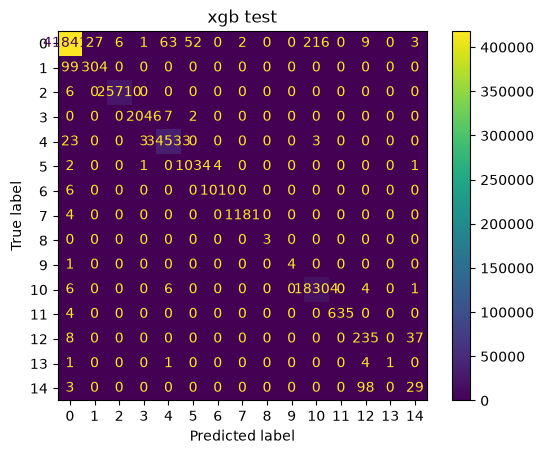

In [55]:
evaluate(preds, y_test, le.classes_, "xgb test")

In [34]:
le.classes_

array(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
       'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed',
       'Infiltration', 'PortScan', 'SSH-Patator',
       'Web Attack  Brute Force', 'Web Attack  Sql Injection',
       'Web Attack  XSS'], dtype=object)

--- xgb test ---
accuracy: 0.9988
                           precision    recall  f1-score   support

                   BENIGN       1.00      1.00      1.00    418794
                      Bot       0.96      0.75      0.84       403
                     DDoS       1.00      1.00      1.00     25716
            DoS GoldenEye       1.00      1.00      1.00      2055
                 DoS Hulk       1.00      1.00      1.00     34562
         DoS Slowhttptest       0.99      0.99      0.99      1042
            DoS slowloris       0.99      0.99      0.99      1016
              FTP-Patator       1.00      1.00      1.00      1185
               Heartbleed       1.00      1.00      1.00         3
             Infiltration       1.00      0.80      0.89         5
                 PortScan       0.99      1.00      0.99     18321
              SSH-Patator       1.00      1.00      1.00       639
  Web Attack  Brute Force       0.70      0.83      0.76       280
Web Attack  Sql Injection  

array([0, 0, 0, ..., 0, 0, 0], shape=(504158,))

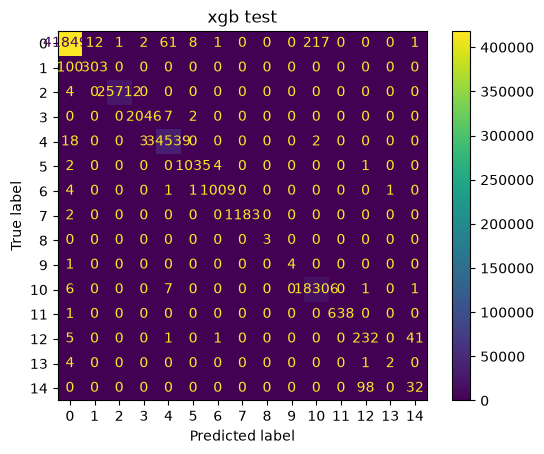

In [33]:
evaluate(preds, y_test, le.classes_, "xgb test")